In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
all_tornados = pd.read_csv('data/1950-2021_actual_tornadoes.csv')

In [3]:
all_tornados

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,len,wid,ns,sn,sg,f1,f2,f3,f4,fc
0,192,1950,10,1,1950-10-01,21:00:00,3,OK,40,23,...,15.80,10,1,1,1,25,0,0,0,0
1,193,1950,10,9,1950-10-09,02:15:00,3,NC,37,9,...,2.00,880,1,1,1,47,0,0,0,0
2,195,1950,11,20,1950-11-20,02:20:00,3,KY,21,1,...,0.10,10,1,1,1,177,0,0,0,0
3,196,1950,11,20,1950-11-20,04:00:00,3,KY,21,2,...,0.10,10,1,1,1,209,0,0,0,0
4,197,1950,11,20,1950-11-20,07:30:00,3,MS,28,14,...,2.00,37,1,1,1,101,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67553,620523,2021,9,8,2021-09-08,15:32:00,3,PA,42,0,...,0.73,30,1,1,1,109,0,0,0,0
67554,620524,2021,9,8,2021-09-08,15:35:00,3,PA,42,0,...,1.45,30,1,1,1,109,0,0,0,0
67555,620525,2021,9,8,2021-09-08,19:08:00,3,FL,12,0,...,1.45,50,1,1,1,129,0,0,0,0
67556,620526,2021,9,9,2021-09-09,02:10:00,3,CT,9,0,...,0.75,75,1,1,1,13,0,0,0,0


In [4]:
sel_states = ['IL']
Midwest_Tornadoes = all_tornados[all_tornados['st'].isin(sel_states)]
Midwest_Tornadoes.set_index(pd.to_datetime(Midwest_Tornadoes['date']), inplace = True)
Midwest_tor_count = Midwest_Tornadoes.resample('MS').size()


In [5]:
EPNA_data = pd.read_csv('data/EPNA_1951_2025')
EPNA_data.rename(columns = {'Date': 'date'}, inplace = True)
EPNA_data['date'] = pd.to_datetime(EPNA_data['date'])
EPNA_data.set_index('date', inplace = True)

Mw_Tor_Tele = pd.merge(left = Midwest_tor_count.rename('monthly_count'), right = EPNA_data, on = 'date', how = 'inner')

In [6]:
Mw_Tor_Tele

,monthly_count,ENSO,PDO,NAO,AO
date,,,,,
1951-01-01,0,1.5,-1.19,0.08,-0.085
1951-02-01,0,0.9,-1.52,0.70,-0.400
1951-03-01,0,-0.1,-1.72,-1.02,-1.934
1951-04-01,0,-0.3,-1.35,-0.22,-0.776
1951-05-01,0,-0.7,-1.29,-0.59,-0.863
...,...,...,...,...,...
2021-08-01,16,0.6,-0.95,-0.28,-0.209
2021-09-01,0,0.8,-1.96,-0.21,-0.252
2021-10-01,10,0.7,-3.13,-2.29,-0.146


In [7]:
# Checking for missing values

Mw_Tor_Tele.isna().sum()

monthly_count    0
ENSO             0
PDO              0
NAO              0
AO               0
dtype: int64

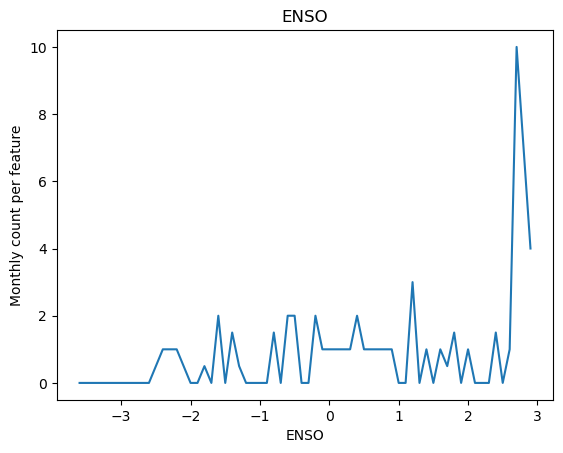

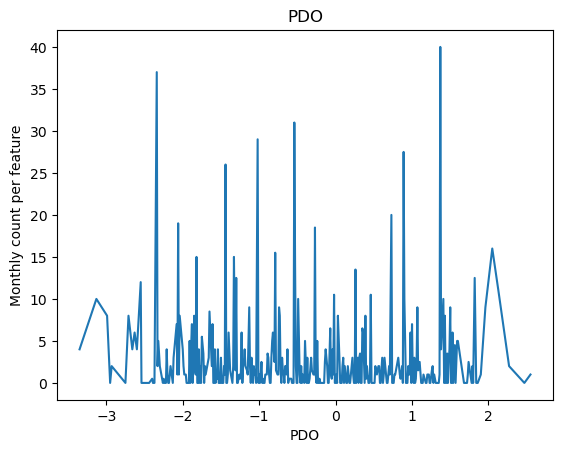

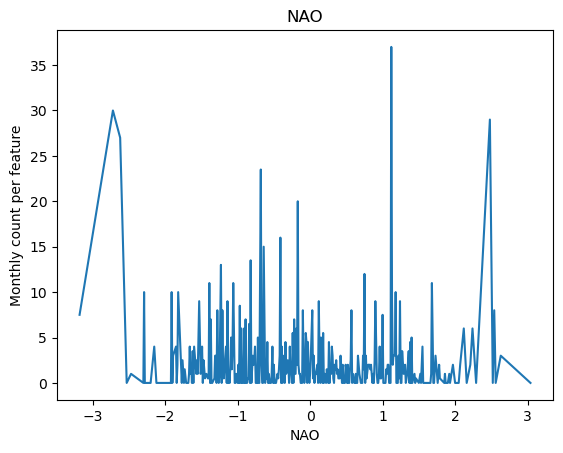

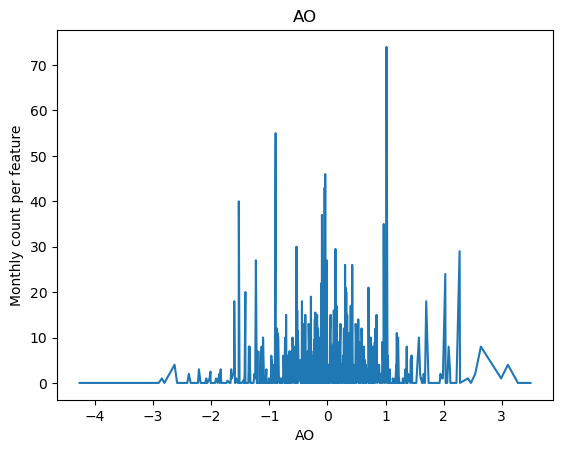

In [8]:
training_features = ['ENSO', 'PDO', 'NAO', 'AO']

for feature in training_features:
    Mw_Tor_Tele.groupby(feature)['monthly_count'].median().plot()
    plt.ylabel('Monthly count per feature')
    plt.title(feature)
    plt.show()

In [30]:
Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop(['monthly_count'], axis = 1)

In [33]:
param_grid = {
 "max_depth": [10, 25, 50, 100],
 "learning_rate": [0.01, 0.1, 0.5, 0.7],
 "min_samples_leaf": [1,2,3,4,5],
 "n_estimators": [25, 50, 100, 200, 400]}

grid = GridSearchCV(GradientBoostingRegressor(), param_grid=param_grid, cv = 7)



In [34]:
grid.fit(X,Y)

,estimator,GradientBoostingRegressor()
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [10, 25, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [25, 50, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,7
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [36]:
grid.best_params_

{'learning_rate': 0.01,
 'max_depth': 100,
 'min_samples_leaf': 5,
 'n_estimators': 25}

{'learning_rate': 0.01,
 'max_depth': 100,
 'min_samples_leaf': 5,
 'n_estimators': 25}

In [39]:
grid.cv_results_

{'mean_fit_time': array([0.05198336, 0.1019625 , 0.20486525, 0.40972127, 0.8128422 ,
        0.05044484, 0.10026758, 0.19821654, 0.39640784, 0.79015953,
        0.04880915, 0.09740295, 0.19354878, 0.38520363, 0.77080641,
        0.04774295, 0.09438252, 0.19200407, 0.37911156, 0.75602811,
        0.04696396, 0.09334421, 0.18649834, 0.36860391, 0.74036598,
        0.07343132, 0.14591013, 0.28846087, 0.56407693, 1.12167961,
        0.06472404, 0.12968707, 0.26341758, 0.55308608, 1.17384069,
        0.05895829, 0.11742885, 0.2384588 , 0.51149024, 1.10072412,
        0.05406145, 0.10822501, 0.22377127, 0.48483317, 1.03829271,
        0.05101088, 0.10125685, 0.20989629, 0.44781317, 0.94937495,
        0.07252894, 0.14165146, 0.28519092, 0.56888219, 1.1238808 ,
        0.06552379, 0.13033482, 0.26150996, 0.55333597, 1.1712903 ,
        0.05874484, 0.11793011, 0.23787669, 0.52030591, 1.10496943,
        0.05384445, 0.10776087, 0.22417055, 0.47996136, 1.04768164,
        0.05096735, 0.10142418,

In [17]:
Y = Mw_Tor_Tele['monthly_count']
X = Mw_Tor_Tele.drop('monthly_count', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25 )

In [34]:
gbr_model_opt = GradientBoostingRegressor(learning_rate = 0.1,
                                      max_depth = 100,
                                      min_samples_leaf = 5,
                                      n_estimators = 25)
gbr_model_opt.fit(X_train, y_train)
gbr_predicted_opt = gbr_model_opt.predict(X_test)

gbr_opt_R2 = r2_score(y_test, gbr_predicted_opt)
gbr_opt_rmse = root_mean_squared_error(y_test, gbr_predicted_opt)

print("R2 Score the Gradient Boosting Regression is ", gbr_opt_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_opt_rmse)



R2 Score the Gradient Boosting Regression is  -0.28143887311367344
RMSE Score the Gradient Boosting Regression is  5.751402356015098


In [35]:
gbr_model = GradientBoostingRegressor()
gbr_model.fit(X_train, y_train)
gbr_model.score(X_test, y_test)

gbr_model.fit(X_train, y_train)
gbr_predicted = gbr_model.predict(X_test)

gbr_R2 = r2_score(y_test, gbr_predicted)
gbr_rmse = root_mean_squared_error(y_test, gbr_predicted)

print("R2 Score the Gradient Boosting Regression is ", gbr_R2)
print("RMSE Score the Gradient Boosting Regression is ", gbr_rmse)

R2 Score the Gradient Boosting Regression is  -0.19729376142705868
RMSE Score the Gradient Boosting Regression is  5.5593646801371355
